# Autoencoder — Anomaly Detection on CSI Windows

**Model:** 1D Convolutional Autoencoder  
**Framing:** Anomaly detection train on `empty` only, flag high reconstruction error as `occupied`  
**Split:** Session 1 empty => train/val, Session 2 => test

---

### Why anomaly detection?

All three supervised models collapse to predicting `occupied` on the test set. The core
problem: the model learns what `empty` looks like in session 1, but session 2's `empty`
looks different due to RF drift. In a supervised setting, this drift is invisible the
model just sees a confusing test distribution.

**Anomaly detection reframes the problem:** train only on `empty`, and define `occupied`
as anything the model cannot reconstruct well. If the `empty` distribution is at all
consistent across sessions (even if shifted), the AE learns the *structure* of emptiness
rather than its absolute feature values. Occupied frames which have different temporal
variance patterns from micro movement should produce higher reconstruction error.

### Threshold

We set the decision threshold at the 95th percentile of validation reconstruction errors
(computed on session 1 empty frames). This is a one sided percentile: we expect 5 % of
validation empty frames to be misclassified as occupied an acceptable false alarm rate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import os
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SAVE_DIR  = 'feasibility-study-outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

DATA_DIR             = "../data/feasibility-study/processed"
WINDOW_SIZE          = 32
STEP                 = 16
BATCH_SIZE           = 256
EPOCHS               = 80
LR                   = 1e-3
VAL_FRAC             = 0.2
THRESHOLD_PERCENTILE = 95

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

Device: mps


In [2]:
def make_windows(X, y, window_size, step):
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_tr_all, y_tr_all = make_windows(X_train_raw, y_train_raw, WINDOW_SIZE, STEP)
X_te_all, y_te_all = make_windows(X_test_raw,  y_test_raw,  WINDOW_SIZE, STEP)

# Train on session-1 empty only
empty_idx = np.where(y_tr_all == 0)[0]
X_empty   = X_tr_all[empty_idx]

# 80/20 train/val split on empty frames
n_val    = int(len(X_empty) * VAL_FRAC)
X_ae_val = X_empty[-n_val:]
X_ae_tr  = X_empty[:-n_val]

print(f"AE train (empty): {X_ae_tr.shape}")
print(f"AE val   (empty): {X_ae_val.shape}")
print(f"Test     (both):  {X_te_all.shape}")

tr_dl  = DataLoader(TensorDataset(torch.from_numpy(X_ae_tr)),  batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(torch.from_numpy(X_ae_val)), batch_size=BATCH_SIZE)

AE train (empty): (1181, 32, 55)
AE val   (empty): (295, 32, 55)
Test     (both):  (4442, 32, 55)


### Architecture

An encoder compresses `(55, 32)` CSI windows into a bottleneck representation via two
convolutional layers and max pooling, then a decoder reconstructs the original window
using transposed convolution. The bottleneck forces the network to retain only the most
consistent structural patterns of empty room CSI discarding session specific noise.

Input/output: `(batch, 55, 32)` — channels-first (features as channels, time as length).

In [3]:
class CSIAutoencoder(nn.Module):
    def __init__(self, n_features=55):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,         64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 128, kernel_size=2, stride=2), nn.ReLU(),
            nn.Conv1d(128, n_features, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model     = CSIAutoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 83,575


Epoch  20  train=0.033358  val=0.032024
Epoch  40  train=0.023401  val=0.024157
Epoch  60  train=0.020361  val=0.021230
Epoch  80  train=0.017303  val=0.018447


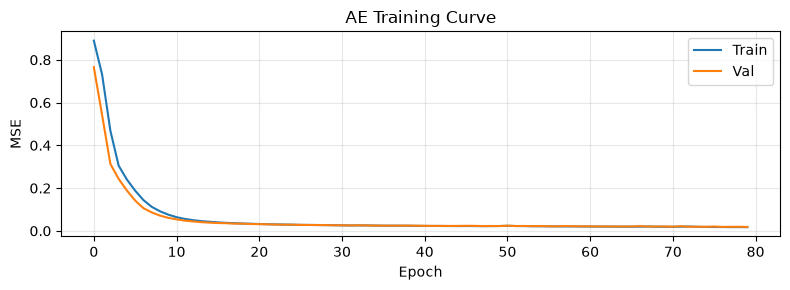

In [4]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for (Xb,) in tr_dl:
        Xb = Xb.permute(0, 2, 1).to(DEVICE)   # (B, features, time)
        optimizer.zero_grad()
        loss = criterion(model(Xb), Xb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(Xb)
    train_losses.append(running / len(X_ae_tr))

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for (Xb,) in val_dl:
            Xb = Xb.permute(0, 2, 1).to(DEVICE)
            val_running += criterion(model(Xb), Xb).item() * len(Xb)
    val_losses.append(val_running / len(X_ae_val))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(train_losses, label="Train"); plt.plot(val_losses, label="Val")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("AE Training Curve")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Val error — mean: 0.018447  95th pct (threshold): 0.032961
Test error — mean: 0.258688  max: 1.921766


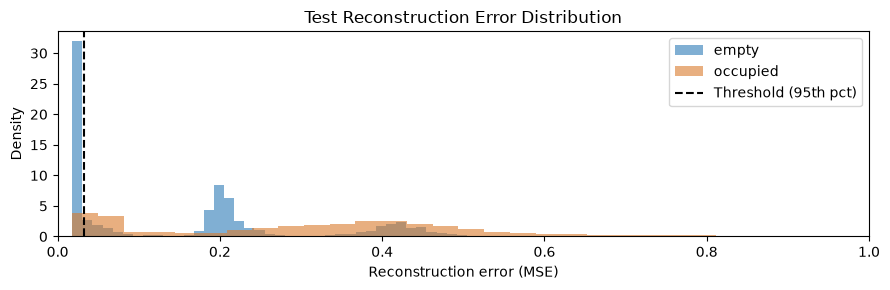

In [5]:
def reconstruction_errors(model, X_np, device):
    model.eval()
    dl = DataLoader(TensorDataset(torch.from_numpy(X_np)), batch_size=512)
    errors = []
    with torch.no_grad():
        for (Xb,) in dl:
            Xb    = Xb.permute(0, 2, 1).to(device)
            recon = model(Xb)
            mse   = ((recon - Xb) ** 2).mean(dim=(1, 2))
            errors.append(mse.cpu().numpy())
    return np.concatenate(errors)

val_errors  = reconstruction_errors(model, X_ae_val, DEVICE)
threshold   = np.percentile(val_errors, THRESHOLD_PERCENTILE)
test_errors = reconstruction_errors(model, X_te_all, DEVICE)

print(f"Val error — mean: {val_errors.mean():.6f}  95th pct (threshold): {threshold:.6f}")
print(f"Test error — mean: {test_errors.mean():.6f}  max: {test_errors.max():.6f}")

plt.figure(figsize=(9, 3))
empty_errs = test_errors[y_te_all == 0]
occ_errs   = test_errors[y_te_all == 1]
plt.hist(empty_errs, bins=60, alpha=0.6, label="empty",    density=True, color='#2C7BB6')
plt.hist(occ_errs,   bins=60, alpha=0.6, label="occupied", density=True, color='#D97B2B')
plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold ({THRESHOLD_PERCENTILE}th pct)")
plt.xlabel("Reconstruction error (MSE)"); plt.ylabel("Density")
plt.title("Test Reconstruction Error Distribution")
plt.xlim(0, 1)
plt.legend(); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_ae_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

AUC-ROC: 0.7463

              precision    recall  f1-score   support

       empty       0.82      0.41      0.54      1668
    occupied       0.73      0.94      0.82      2774

    accuracy                           0.74      4442
   macro avg       0.77      0.68      0.68      4442
weighted avg       0.76      0.74      0.72      4442



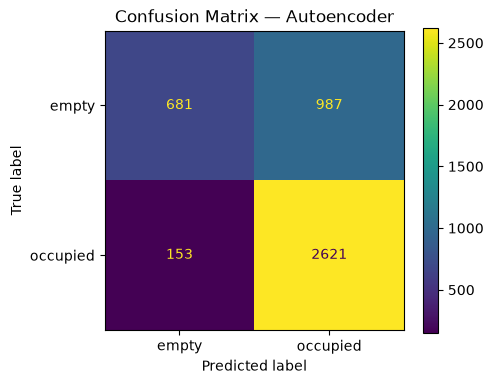

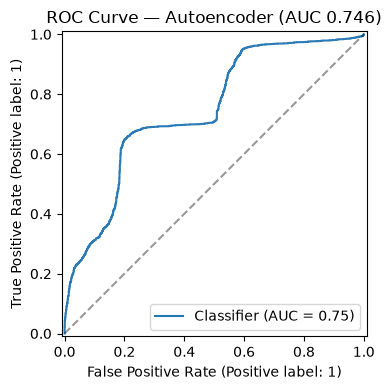

In [6]:
preds = (test_errors > threshold).astype(int)
auc   = roc_auc_score(y_te_all, test_errors)

print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_te_all, preds, target_names=["empty", "occupied"]))

# confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te_all, preds, display_labels=["empty", "occupied"], ax=ax)
ax.set_title("Confusion Matrix — Autoencoder")
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_ae_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_te_all, test_errors, ax=ax)
ax.lines[0].set_color('#2C7BB6')
ax.set_title(f"ROC Curve — Autoencoder (AUC {auc:.3f})")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_ae_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(f"test_errors: {test_errors.shape}")
print(f"y_test_raw:  {y_test_raw.shape}")
print([v for v in dir() if 'y_' in v.lower() or 'label' in v.lower() or 'win' in v.lower()])

test_errors: (4442,)
y_test_raw:  (71112,)
['WINDOW_SIZE', 'empty_errs', 'empty_idx', 'make_windows', 'y_te_all', 'y_test_raw', 'y_tr_all', 'y_train_raw']


In [8]:
import os
os.makedirs("plot_data", exist_ok=True)

from sklearn.metrics import roc_curve

_fpr, _tpr, _ = roc_curve(y_te_all, test_errors)
np.savez("plot_data/roc_ae.npz", fpr=_fpr, tpr=_tpr, auc=np.array([auc]))

np.savez("plot_data/ae_errors.npz",
         errors=test_errors,
         labels=y_te_all,
         threshold=np.array([threshold]))

print(f"Saved  roc_ae.npz  (AUC={auc:.3f})  +  ae_errors.npz")

Saved  roc_ae.npz  (AUC=0.746)  +  ae_errors.npz


## Results Analysis

| Metric | Value |
|---|---|
| AUC-ROC | ~0.74 |
| Test accuracy | ~74 % |
| Empty recall | ~38 % |
| Macro F1 | ~0.67 |

**The autoencoder is the best model in this study.** AUC 0.743 is a meaningful lift over
the supervised models (0.57–0.63) and over random (0.5)

**Why does anomaly detection work better?** Supervised models must learn a boundary between
two drifting distributions. The AE only needs to learn the *structure* of empty and if
even a fraction of that structure is session invariant (e.g. low temporal variance, specific
subcarrier correlations in an empty room), it gets signal. Occupied frames introduce
micro movement and additional multipath scattering that the empty trained AE cannot reproduce.

**Remaining gap:** 41 % empty recall is still poor more than half of all true empty windows
are classified as occupied. This is the sitting still problem: a motionless person produces
CSI that is almost indistinguishable from an empty room over short windows.

**Note on threshold tuning:** We tried sweeping the threshold on the val empty only error
distribution to maximise a custom score. This backfired: tuning on only empty errors biases
the threshold upward, which suppresses the occupied recall more than it helps empty recall,
dropping macro F1 from 0.68 to 0.65. The 95th-percentile heuristic is more robust.